# Worked Example

This page walks through a complete `vqlp` workflow on synthetic data:

1. Generate synthetic data (`sklearn.make_blobs`)
2. Fit prototypes via FAISS k-means (`VQFitter`)
3. Run full recall analysis on the learned prototypes (`VQRecaller`)
4. Plot the data, prototypes, and the connectivity (CONN) graph
5. Inspect the recall products (BMU, QE, receptive fields, connectivity, reconstruction)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

from vqlp import VQFitter

## 1. Generate synthetic data

We create six Gaussian blobs in 2D so the result is easy to plot. We ask for
more prototypes (`M = 20`) than there are blobs, which produces a richer
connectivity (CONN) structure across each blob.


In [2]:
N_SAMPLES = 500
N_BLOBS   = 6
N_FEATURES = 2      # 2D so we can plot it easily
M_PROTOTYPES = 20   # more prototypes than blobs to get interesting CONN structure

X, true_labels = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    centers=N_BLOBS,
    cluster_std=0.8,
    random_state=42
)
print(f"Data shape: {X.shape}")

Data shape: (500, 2)


## 2. Fit prototypes

With `p=2` (Euclidean), `VQFitter` defaults to the FAISS k-means backend. We
run several restarts (`nredo=3`) and keep the best result. After fitting, the
prototype matrix is available as `fitter.W` with shape `(M, d)`.


In [3]:
fitter = VQFitter(M=M_PROTOTYPES, p=2, max_bmu=2, random_state=42)
fitter.fit(X, method="kmeans", niter=30, nredo=3)

W = fitter.W   # prototype matrix, shape (M, d)
print(f"Prototype matrix shape: {W.shape}")

Running FAISS k-means with 20 clusters (niter=30, nredo=3)...
K-means complete. Final MQE: 0.507609
Fitting complete using kmeans method.
Prototype matrix shape: (20, 2)


WARNING clustering 500 points to 20 centroids: please provide at least 780 training points


## 3. Full recall analysis

`recall()` finalizes the recall products (receptive fields, connectivity, etc.)
on the training data. The underlying `VQRecaller` is exposed as
`fitter.recaller`.


In [4]:
fitter.recall()        # finalizes RF, CONN etc. on training data
recaller = fitter.recaller

Receptive fields computed.
Connectivity matrix computed.
Recall analysis complete. MQE: 0.507609


## 4. Visualize assignments and connectivity

The left panel colours each observation by its best-matching unit (BMU) and
overlays the prototypes. The right panel draws the CONN graph: edges weighted by
connectivity strength, nodes sized by receptive-field size.


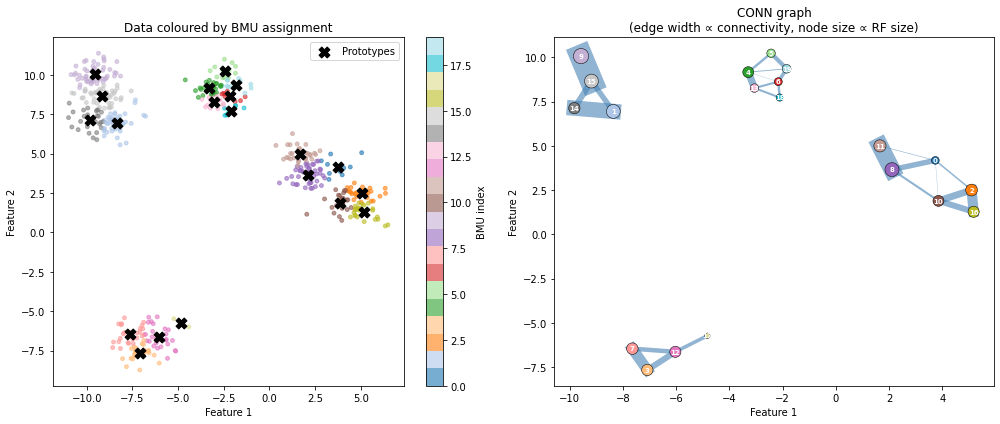

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: data coloured by BMU assignment --------------------------
ax = axes[0]
ax.set_title("Data coloured by BMU assignment")

bmu_ids = recaller.BMU[:, 0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=bmu_ids, cmap="tab20",
                     s=15, alpha=0.6, zorder=1)
ax.scatter(W[:, 0], W[:, 1], c="black", marker="X", s=120,
           zorder=3, label="Prototypes")
ax.legend(loc="upper right")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.colorbar(scatter, ax=ax, label="BMU index")

# --- Right panel: prototype connectivity (CONN) graph ---------------------
ax = axes[1]
ax.set_title("Prototype connectivity (CONN) graph")

# Draw edges weighted by CONN value
conn_csr = recaller.CONN.tocsr()
for i in range(recaller._M):
    for j in recaller.CONN_nhbs[i]:
        if j <= i:   # draw each edge once
            continue
        weight = conn_csr[i, j]
        ax.plot([W[i, 0], W[j, 0]],
                [W[i, 1], W[j, 1]],
                color="steelblue", linewidth=weight * 0.3, alpha=0.6, zorder=1)

# Prototypes sized by receptive field size
rf_sizes = recaller.RFSize
ax.scatter(W[:, 0], W[:, 1],
           s=rf_sizes * 4 + 20,
           c=np.arange(M_PROTOTYPES), cmap="tab20",
           edgecolors="black", linewidths=0.5, zorder=2)

for i, (x, y) in enumerate(W):
    ax.annotate(str(i), (x, y), fontsize=7, ha="center", va="center",
                color="white", fontweight="bold", zorder=3)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("CONN graph\n(edge width ∝ connectivity, node size ∝ RF size)")

plt.tight_layout()
plt.show()

## 5. Inspect the recall products

`get_summary()` returns aggregate statistics. Below it we look at the per-observation
BMU/QE arrays, the receptive fields, the connectivity matrix, and finally hard vs.
soft reconstruction error.


In [6]:
print("--- get_summary() ---")
summary = fitter.get_summary()
for k, v in summary.items():
    print(f"  {k:35s}: {v}")

--- get_summary() ---
  fitted                             : True
  M                                  : 20
  d                                  : 2
  p_norm                             : 2
  max_bmu                            : 2
  random_state                       : 42
  N                                  : 500
  index_type                         : flat
  mean_quantization_error            : 0.5076089868769049
  empty_prototypes                   : 0
  largest_rf_size                    : 53
  connectivity_edges                 : 26
  mean_connectivity_degree           : 2.6
  max_connectivity_degree            : 4


In [7]:
print("--- BMU & QE (first 8 observations) ---")
print(f"  BMU shape : {recaller.BMU.shape}   (N x max_bmu)")
print(f"  QE  shape : {recaller.QE.shape}   (N x max_bmu)")
for i in range(8):
    print(f"  obs {i:3d}  |  1st BMU: {recaller.BMU[i,0]:3d}  QE1: {recaller.QE[i,0]:.4f}"
          f"  |  2nd BMU: {recaller.BMU[i,1]:3d}  QE2: {recaller.QE[i,1]:.4f}")

--- BMU & QE (first 8 observations) ---
  BMU shape : (500, 2)   (N x max_bmu)
  QE  shape : (500, 2)   (N x max_bmu)
  obs   0  |  1st BMU:  16  QE1: 0.2925  |  2nd BMU:  10  QE2: 1.0077
  obs   1  |  1st BMU:   9  QE1: 0.2430  |  2nd BMU:  15  QE2: 3.8245
  obs   2  |  1st BMU:   9  QE1: 1.0912  |  2nd BMU:  15  QE2: 4.1360
  obs   3  |  1st BMU:  10  QE1: 3.7886  |  2nd BMU:   8  QE2: 6.2403
  obs   4  |  1st BMU:  14  QE1: 0.2723  |  2nd BMU:   1  QE2: 3.9224
  obs   5  |  1st BMU:  10  QE1: 0.1096  |  2nd BMU:   2  QE2: 1.2015
  obs   6  |  1st BMU:   1  QE1: 0.5480  |  2nd BMU:  15  QE2: 2.8941
  obs   7  |  1st BMU:   9  QE1: 1.7255  |  2nd BMU:  15  QE2: 7.3617


In [8]:
print("--- Receptive fields (RF) ---")
print(f"  RFSize range: {recaller.RFSize.min()} - {recaller.RFSize.max()} observations")
print(f"  Empty prototypes: {int(np.sum(recaller.RFSize == 0))}")
for i in range(min(5, M_PROTOTYPES)):
    print(f"  RF[{i}]: {recaller.RFSize[i]:3d} obs  ->  indices {recaller.RF[i][:6]}{'...' if recaller.RFSize[i] > 6 else ''}")

--- Receptive fields (RF) ---
  RFSize range: 2 - 53 observations
  Empty prototypes: 0
  RF[0]:  10 obs  ->  indices [41, 115, 150, 168, 190, 196]...
  RF[1]:  43 obs  ->  indices [6, 25, 43, 49, 50, 57]...
  RF[2]:  30 obs  ->  indices [10, 16, 53, 70, 71, 96]...
  RF[3]:  27 obs  ->  indices [18, 19, 97, 114, 128, 134]...
  RF[4]:  25 obs  ->  indices [26, 31, 42, 176, 177, 181]...


In [9]:
print("--- Connectivity matrix (CONN) ---")
print(f"  CONN shape  : {recaller.CONN.shape}   (M x M, sparse)")
print(f"  Nonzero entries: {recaller.CONN.nnz}  ({summary['connectivity_edges']} unique edges)")
print(f"  Degree range: {recaller.CONN_nhbs_size.min()} - {recaller.CONN_nhbs_size.max()} neighbours")
print(f"  Mean degree : {summary['mean_connectivity_degree']:.2f}")
for i in range(min(5, M_PROTOTYPES)):
    print(f"  Prototype {i:2d}: {recaller.CONN_nhbs_size[i]} neighbours  ->  {recaller.CONN_nhbs[i]}")

--- Connectivity matrix (CONN) ---
  CONN shape  : (20, 20)   (M x M, sparse)
  Nonzero entries: 52  (26 unique edges)
  Degree range: 1 - 4 neighbours
  Mean degree : 2.60
  Prototype  0: 4 neighbours  ->  [2, 8, 10, 11]
  Prototype  1: 2 neighbours  ->  [14, 15]
  Prototype  2: 3 neighbours  ->  [0, 10, 16]
  Prototype  3: 2 neighbours  ->  [7, 12]
  Prototype  4: 4 neighbours  ->  [5, 6, 13, 19]


In [10]:
print("--- Reconstruction ---")
X_hard = recaller.reconstruct(W, X, method="hard")
X_soft = recaller.reconstruct(W, X, method="soft")
hard_err = np.mean(np.linalg.norm(X - X_hard, axis=1))
soft_err = np.mean(np.linalg.norm(X - X_soft, axis=1))
print(f"  Hard reconstruction mean L2 error: {hard_err:.4f}")
print(f"  Soft reconstruction mean L2 error: {soft_err:.4f}")

--- Reconstruction ---
Soft reconstruction complete.
  Hard reconstruction mean L2 error: 0.6287
  Soft reconstruction mean L2 error: 0.6148
